In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__huggingface_repos__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/custom.css
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/desperation_global_local.png
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/scree_full.png
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/direction_norms_by_layer.png
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/activations.pkl
/kaggle/input/notebooks/bencarson/gem

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
ACTS_PATH = '/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/emotions_phase1/activations.pkl'  # adjust
NRC_PATH  = '/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt'
LAYER     = 25

with open(ACTS_PATH, 'rb') as f:
    saved = pickle.load(f)

resid_acts = saved['resid']  # {emotion: [n_stories, n_layers, d_model]}

nrc = pd.read_csv(NRC_PATH, sep='\t', header=0,
                  names=['word', 'valence', 'arousal', 'dominance'])
nrc = nrc.drop_duplicates('word').set_index('word')


In [4]:
# ── Cell 3: Compute mean directions at layer 25 ──────────────────────────────
neutral_stories = resid_acts['__neutral__']        # [n_neutral, n_layers, d_model]
neutral_mean    = neutral_stories[:, LAYER, :].mean(axis=0)  # [d_model]

emotion_names, directions = [], []
for name, arr in resid_acts.items():
    if name == '__neutral__':
        continue
    mean_at_layer = arr[:, LAYER, :].mean(axis=0)  # [d_model]
    directions.append(mean_at_layer - neutral_mean)
    emotion_names.append(name)

directions = np.array(directions)  # [174, 1536]
print(f"Direction matrix: {directions.shape}")


Direction matrix: (174, 1536)


In [5]:
# ── Cell 4: Match to NRC-VAD ─────────────────────────────────────────────────
def lookup_vad(name):
    word = name.replace('_', ' ').lower()
    if word in nrc.index:
        return nrc.loc[word, ['valence', 'arousal', 'dominance']].values.astype(float)
    first = word.split()[0]
    if first in nrc.index:
        return nrc.loc[first, ['valence', 'arousal', 'dominance']].values.astype(float)
    return None

vad_rows, kept_names, kept_dirs, missing = [], [], [], []
for name, direction in zip(emotion_names, directions):
    row = lookup_vad(name)
    if row is not None:
        vad_rows.append(row)
        kept_names.append(name)
        kept_dirs.append(direction)
    else:
        missing.append(name)

if missing:
    print(f"No NRC entry for: {missing}")

vad  = np.array(vad_rows)   # [N, 3]  — valence, arousal, dominance
dirs = np.array(kept_dirs)  # [N, 1536]
print(f"Matched {len(kept_names)}/{len(emotion_names)} emotions")


No NRC entry for: ['energized', 'insulted', 'stimulated']
Matched 171/174 emotions


In [6]:
# ── Cell 5: PCA ──────────────────────────────────────────────────────────────
N_PCS = 50
pca    = PCA(n_components=N_PCS)
scores = pca.fit_transform(dirs)  # [N, 50]

cumvar = np.cumsum(pca.explained_variance_ratio_)
for k in [3, 5, 10, 16, 20, 36]:
    if k <= N_PCS:
        print(f"  {k:2d} PCs → {cumvar[k-1]*100:.1f}% variance")


   3 PCs → 52.4% variance
   5 PCs → 61.6% variance
  10 PCs → 73.7% variance
  16 PCs → 80.6% variance
  20 PCs → 83.6% variance
  36 PCs → 90.3% variance


In [7]:
# ── Cell 6: Per-PC correlation table — V, A, D ───────────────────────────────
dim_names = ['valence', 'arousal', 'dominance']
N_SHOW    = 20
rows = []
for i in range(N_SHOW):
    row = {'PC': i+1, 'var%': f"{pca.explained_variance_ratio_[i]*100:.1f}"}
    for j, dim in enumerate(dim_names):
        r, p = stats.pearsonr(scores[:, i], vad[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row[f'{dim}_r'] = f"{r:+.3f}{sig}"
    rows.append(row)

print(pd.DataFrame(rows).set_index('PC').to_string())

    var%  valence_r  arousal_r dominance_r
PC                                        
1   37.4  -0.403***   +0.206**   -0.328***
2    8.8  +0.378***     +0.029   +0.305***
3    6.3   +0.232**  -0.281***      -0.018
4    5.2  +0.457***     +0.134   +0.422***
5    4.0     +0.084     +0.088   +0.302***
6    3.3     +0.012  -0.475***     -0.175*
7    2.5   +0.223**     +0.078      +0.114
8    2.4     -0.082     -0.083    -0.224**
9    2.3    +0.185*   -0.228**      -0.075
10   1.7     -0.116     -0.122      -0.098
11   1.3     +0.020     -0.009      -0.062
12   1.3     +0.033     -0.112      +0.000
13   1.2     -0.011     +0.041      -0.060
14   1.1     -0.047     -0.069      -0.014
15   1.0     +0.148     -0.116      +0.092
16   0.9     -0.013    +0.157*      +0.103
17   0.9     -0.104   +0.234**      -0.033
18   0.8     -0.005     +0.047      -0.034
19   0.7     +0.134     +0.126      +0.103
20   0.7     +0.009     +0.008      -0.043


In [8]:
# ── Cell 7: Cumulative R² — which dimension is best explained? ───────────────
print(f"\n{'k':>4}  {'Valence R²':>11}  {'Arousal R²':>11}  {'Dominance R²':>13}  {'best':>8}")
for k in [1, 2, 3, 4, 5, 8, 10, 15, 20]:
    r2s = [
        sum(stats.pearsonr(scores[:, i], vad[:, j])[0]**2 for i in range(k))
        for j in range(3)
    ]
    best = dim_names[np.argmax(r2s)]
    print(f"{k:>4}  {r2s[0]:>11.3f}  {r2s[1]:>11.3f}  {r2s[2]:>13.3f}  {best:>8}")



   k   Valence R²   Arousal R²   Dominance R²      best
   1        0.163        0.042          0.107   valence
   2        0.305        0.043          0.201   valence
   3        0.359        0.122          0.201   valence
   4        0.568        0.140          0.379   valence
   5        0.576        0.148          0.470   valence
   8        0.632        0.386          0.563   valence
  10        0.679        0.453          0.579   valence
  15        0.705        0.485          0.595   valence
  20        0.734        0.583          0.620   valence


In [9]:
# ── Cell 8: What emotions drive each PC? ────────────────────────────────────
N_TOP = 6
for i in range(6):
    s = scores[:, i]
    pos = np.argsort(s)[-N_TOP:][::-1]
    neg = np.argsort(s)[:N_TOP]
    r_v, _ = stats.pearsonr(s, vad[:, 0])
    r_a, _ = stats.pearsonr(s, vad[:, 1])
    r_d, _ = stats.pearsonr(s, vad[:, 2])
    print(f"\nPC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}% var)  "
          f"V={r_v:+.3f}  A={r_a:+.3f}  D={r_d:+.3f}")
    print(f"  +: {', '.join(kept_names[j] for j in pos)}")
    print(f"  −: {', '.join(kept_names[j] for j in neg)}")


PC1  (37.4% var)  V=-0.403  A=+0.206  D=-0.328
  +: surprised, rattled, hysterical, bored, vigilant, dispirited
  −: optimistic, grateful, cheerful, smug, melancholy, amused

PC2  (8.8% var)  V=+0.378  A=+0.029  D=+0.305
  +: self_confident, pleased, triumphant, euphoric, elated, rejuvenated
  −: panicked, unsettled, terrified, trapped, disturbed, alert

PC3  (6.3% var)  V=+0.232  A=-0.281  D=-0.018
  +: heartbroken, loving, sentimental, relaxed, safe, refreshed
  −: offended, frustrated, outraged, stubborn, grumpy, furious

PC4  (5.2% var)  V=+0.457  A=+0.134  D=+0.422
  +: fulfilled, enthusiastic, heartbroken, refreshed, joyful, vibrant
  −: depressed, melancholy, tormented, frightened, self_confident, hateful

PC5  (4.0% var)  V=+0.084  A=+0.088  D=+0.302
  +: valiant, vengeful, invigorated, vindictive, defiant, resigned
  −: sensitive, shaken, amazed, heartbroken, astonished, puzzled

PC6  (3.3% var)  V=+0.012  A=-0.475  D=-0.175
  +: sleepy, grief_stricken, indifferent, resigned,

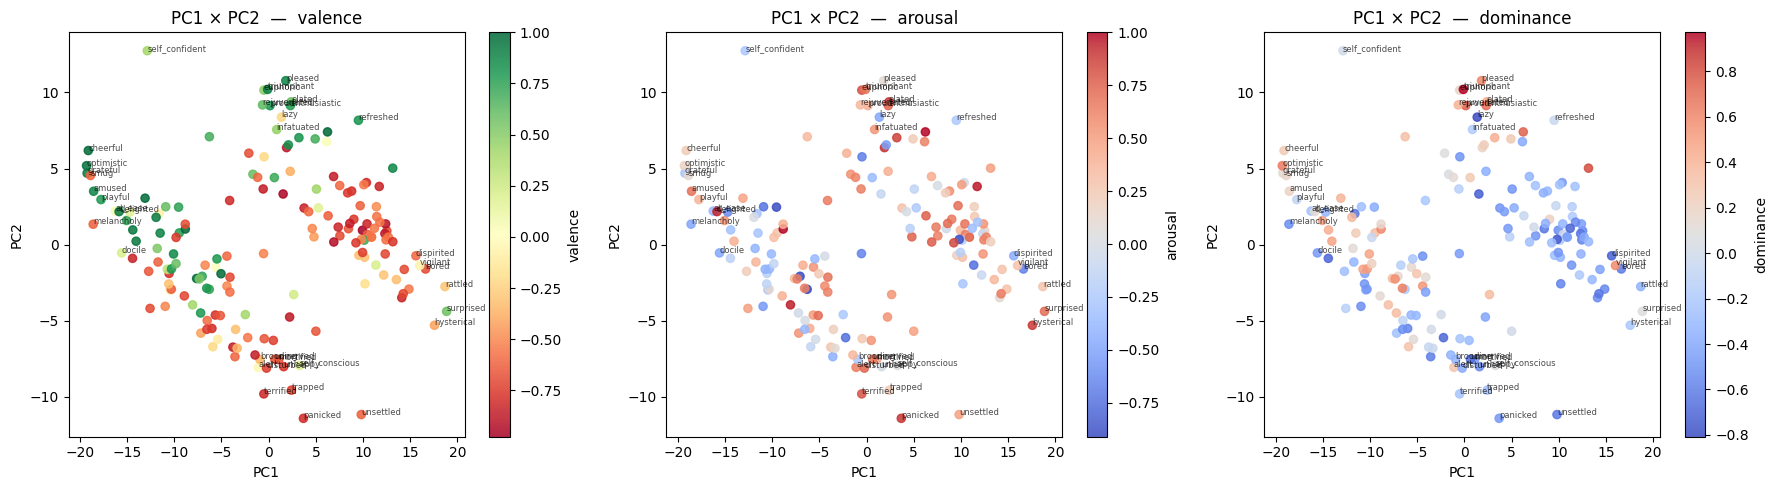

In [10]:
# ── Cell 9: Scatter plots — PC1×PC2 coloured by V, A, D ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (j, dim) in zip(axes, enumerate(dim_names)):
    sc = ax.scatter(scores[:, 0], scores[:, 1],
                    c=vad[:, j], cmap='RdYlGn' if dim == 'valence' else 'coolwarm',
                    s=35, alpha=0.85)
    plt.colorbar(sc, ax=ax, label=dim)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'PC1 × PC2  —  {dim}')
    thresh = 1.6 * scores[:, :2].std(axis=0)
    for name, s_row in zip(kept_names, scores):
        if abs(s_row[0]) > thresh[0] or abs(s_row[1]) > thresh[1]:
            ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)
plt.tight_layout()
plt.savefig('pc1pc2_vad.png', dpi=150)
plt.show()